# Clasificación de textos por década — Parte 1: Machine Learning Clásico

**Competencia:** Aprendizaje de Máquina 2026-10  
**Tarea:** Predecir la **década** (primeros 3 dígitos del año) en que fue escrito un párrafo de texto histórico en español.  
**Clases:** Décadas del `150` al `188` (años 1500–1889), **39 clases** en total.  
**Restricción:** Únicamente modelos de `scikit-learn`, sin redes neuronales ni transformers.

## 1. Importaciones

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
np.random.seed(SEED)

## 2. Carga de datos

In [47]:
df_train = pd.read_csv('data/train.csv')
df_eval  = pd.read_csv('data/eval.csv')

print(f"Train: {df_train.shape}")
print(f"Eval:  {df_eval.shape}")
df_train.head(3)

Train: (31403, 2)
Eval:  (3490, 2)


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157


## 3. Análisis Exploratorio (EDA)

Décadas únicas : 39
Rango          : 150 – 188
Ejemplos/clase : min=754, max=848, media=805


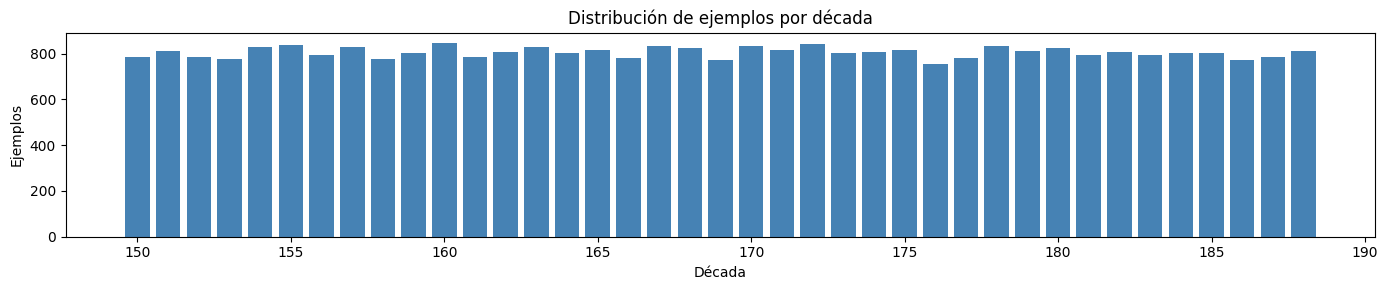

In [48]:
vc = df_train['decade'].value_counts().sort_index()

print(f"Décadas únicas : {df_train['decade'].nunique()}")
print(f"Rango          : {df_train['decade'].min()} – {df_train['decade'].max()}")
print(f"Ejemplos/clase : min={vc.min()}, max={vc.max()}, media={vc.mean():.0f}")

plt.figure(figsize=(14, 3))
plt.bar(vc.index, vc.values, color='steelblue')
plt.xlabel('Década'); plt.ylabel('Ejemplos')
plt.title('Distribución de ejemplos por década')
plt.tight_layout(); plt.show()

count    31403.000000
mean       530.087316
std        539.636593
min        120.000000
25%        185.000000
50%        321.000000
75%        655.000000
max       7480.000000
Name: text, dtype: float64


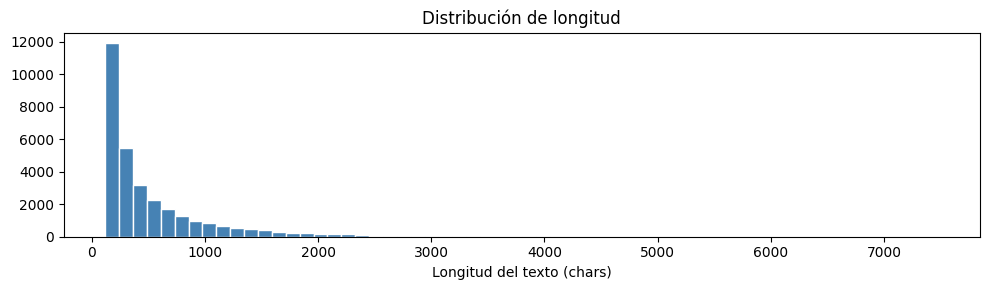

In [49]:
# Longitud de los textos
lens = df_train['text'].str.len()
print(lens.describe())

plt.figure(figsize=(10, 3))
plt.hist(lens, bins=60, color='steelblue', edgecolor='white')
plt.xlabel('Longitud del texto (chars)'); plt.title('Distribución de longitud')
plt.tight_layout(); plt.show()

In [50]:
# Muestra de textos por siglo
for decade in [150, 160, 170, 180, 188]:
    sample = df_train[df_train['decade'] == decade]['text'].iloc[0][:120]
    print(f"Década {decade}: {repr(sample)}\n")

Década 150: 'efiotnl fiiT’e^ pt\\»tf)e 4 trCe et lleene.^^ta^ \r\n41 tT»íi A*e(leee A(ittc(«t>iieii|l>le iié <oii|ette \r\n*iW íléiW^* tem'

Década 160: "blar enla oracion de pereza, i floxedad ,i por eltar medio: \r\ndormido», ifi hablara,fe defpertara,i'avivara para la orar"

Década 170: '\r\n2y. Mas fi no mieote el oido: \r\nReyna. Palos fuenan. Rey. Paños andan \r\nSalen por laswejimas puertas que fe entraromg '

Década 180: '\r\n(87) \r\nobligación  que  las  Ordenanzas  imponen  al  Director \r\ngeneral  de  la  Armada  sobre  el  zelar  que  se  m'

Década 188: '\r\n—  302  — \r\ncapaz  el  corazón  corrompido  del  hombre  inculto  é  iluso.  Y  no \r\ndeja  de  ser  digno  de  notarse'



## 4. Preprocesamiento del texto

Se aplica una limpieza **mínima** para preservar las señales ortográficas históricas que cambiaron entre los siglos XVI y XIX (e.g. uso de la 's' larga escrita como 'f', cambios en 'b/v', ortografía variante, etc.). Esas características son la clave para la clasificación temporal.

In [51]:
def preprocess(text: str) -> str:
    """Limpieza mínima: colapsa saltos de línea y convierte a minúsculas."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = text.lower()
    return re.sub(r' +', ' ', text).strip()

df_train['clean_text'] = df_train['text'].apply(preprocess)
df_eval['clean_text']  = df_eval['text'].apply(preprocess)

print("Original:")
print(repr(df_train['text'].iloc[0][:200]))
print("\nLimpio:")
print(repr(df_train['clean_text'].iloc[0][:200]))

Original:
'\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsiodoro \r\nlib,6.epuft.s 2.Donde * l'

Limpio:
'honorarias ¡jubiladas. 57 dit.ad pontem de poreft.proreg.118,3, $.9.m.-70 pag.4.1. 3 ste ph.gratian. difcept.291, áqu len nes parece que aísilte, o ayuda calsiodoro lib,6.epuft.s 2.donde * llama oclos'


In [52]:
X_train = df_train['clean_text'].values
y_train = df_train['decade'].values
X_eval  = df_eval['clean_text'].values

print(f"Train: {len(X_train)} ejemplos | Eval: {len(X_eval)} ejemplos")

Train: 31403 ejemplos | Eval: 3490 ejemplos


## 5. Pipeline lineal: Char TF-IDF → SelectKBest(chi2) → LogisticRegression

| Paso | Componente | Configuración | Intencionalidad |
|------|-----------|--------------|-----------------|
| 1 | `TfidfVectorizer` | `analyzer='char'`, `ngram_range=(3,5)`, `sublinear_tf=True`, `min_df=5`, `max_df=0.85` | Captura variaciones ortográficas históricas, filtra OCR noise y stopwords de época |
| 2 | `SelectKBest` | `score_func=chi2`, `k=100000` | Reduce dimensionalidad a 100k n-gramas con correlación demostrada |
| 3 | `LogisticRegression` | `solver='saga'`, `class_weight='balanced'`, `max_iter=200` | Maneja superposición de 39 clases, sin sesgo por desbalance |

In [53]:
# División hold-out estratificada (85% train / 15% val)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train
)
print(f"Train: {len(X_tr)} | Val: {len(X_val)}")

Train: 26692 | Val: 4711


In [54]:
# Pipeline lineal: Char TF-IDF → SelectKBest(chi2) → LogisticRegression
C_values = [0.01, 0.1, 0.5, 1.0, 5.0]
results = []

for C in C_values:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            sublinear_tf=True,
            min_df=5,
            max_df=0.85,
        )),
        ('selector', SelectKBest(score_func=chi2, k=100000)),
        ('clf', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            max_iter=200,
            n_jobs=-1,
            C=C,
            random_state=SEED,
        )),
    ])

    print(f"Entrenando con C={C}...", end=' ')
    pipe.fit(X_tr, y_tr)

    tr_acc = accuracy_score(y_tr, pipe.predict(X_tr))
    val_acc = accuracy_score(y_val, pipe.predict(X_val))
    gap = tr_acc - val_acc

    results.append((C, val_acc, tr_acc, gap))
    print(f"train={tr_acc:.4f}  val={val_acc:.4f}  gap={gap:.4f}")

results.sort(key=lambda x: x[1], reverse=True)
best_C = results[0][0]
best_val_acc = results[0][1]
print(f"\n{'='*60}")
print(f"MEJOR: C={best_C}  val_acc={best_val_acc:.4f}")

Entrenando con C=0.01... train=0.3515  val=0.1947  gap=0.1569
Entrenando con C=0.1... train=0.4004  val=0.2078  gap=0.1926
Entrenando con C=0.5... train=0.5460  val=0.2341  gap=0.3119
Entrenando con C=1.0... train=0.6531  val=0.2526  gap=0.4005
Entrenando con C=5.0... train=0.9378  val=0.2711  gap=0.6668

MEJOR: C=5.0  val_acc=0.2711


In [55]:
print("\nResultados de búsqueda de C:")
print(f"{'C':<8s}  {'Val':>8s}  {'Train':>8s}  {'Gap':>8s}")
print("-" * 40)
for C, val_acc, tr_acc, gap in results:
    print(f"{C:<8.2f}  {val_acc:>8.4f}  {tr_acc:>8.4f}  {gap:>8.4f}")
print(f"\nBaseline aleatorio: {1/39:.4f}")


Resultados de búsqueda de C:
C              Val     Train       Gap
----------------------------------------
5.00        0.2711    0.9378    0.6668
1.00        0.2526    0.6531    0.4005
0.50        0.2341    0.5460    0.3119
0.10        0.2078    0.4004    0.1926
0.01        0.1947    0.3515    0.1569

Baseline aleatorio: 0.0256


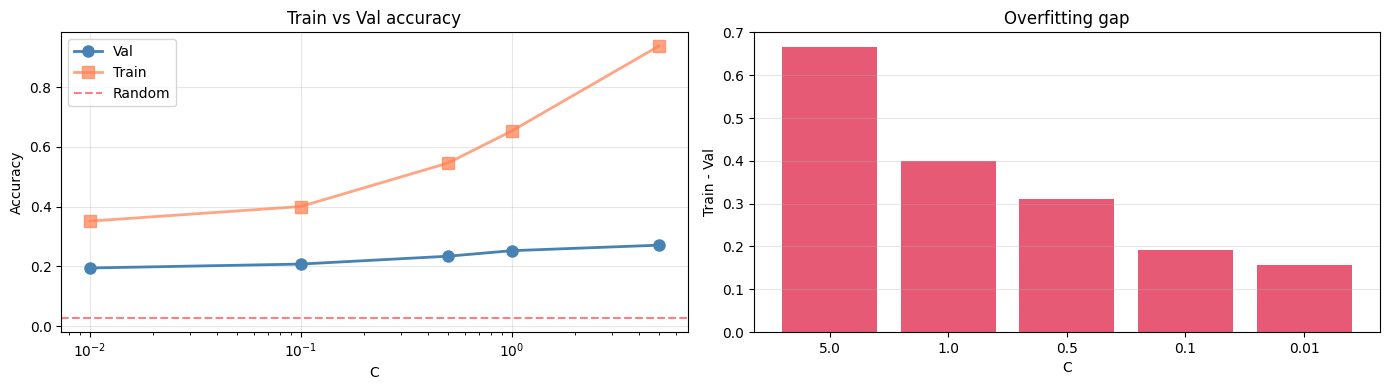

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

C_vals = [r[0] for r in results]
val_accs = [r[1] for r in results]
tr_accs = [r[2] for r in results]
gaps = [r[3] for r in results]

ax1.plot(C_vals, val_accs, 'o-', label='Val', linewidth=2, markersize=8, color='steelblue')
ax1.plot(C_vals, tr_accs, 's-', label='Train', linewidth=2, markersize=8, color='coral', alpha=0.7)
ax1.axhline(1/39, color='red', linestyle='--', alpha=0.5, label='Random')
ax1.set_xlabel('C'); ax1.set_ylabel('Accuracy')
ax1.set_xscale('log'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_title('Train vs Val accuracy')

ax2.bar(range(len(C_vals)), gaps, color='crimson', alpha=0.7)
ax2.set_xticks(range(len(C_vals)))
ax2.set_xticklabels([f'{c}' for c in C_vals])
ax2.set_xlabel('C'); ax2.set_ylabel('Train - Val')
ax2.set_title('Overfitting gap'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

## 6. Entrenamiento del modelo final

Se reentrena el pipeline con el mejor C sobre **todos los datos de entrenamiento**.

In [57]:
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(3, 5),
        sublinear_tf=True,
        min_df=5,
        max_df=0.85,
    )),
    ('selector', SelectKBest(score_func=chi2, k=100000)),
    ('clf', LogisticRegression(
        solver='saga',
        class_weight='balanced',
        max_iter=200,
        n_jobs=-1,
        C=best_C,
        random_state=SEED,
    )),
])

print(f"Mejor C: {best_C}")
print("Reentrenando sobre todos los datos...")
best_pipeline.fit(X_train, y_train)

train_acc = accuracy_score(y_train, best_pipeline.predict(X_train))
print(f"Train accuracy : {train_acc:.4f}")
print(f"Val   accuracy : {best_val_acc:.4f}")

Mejor C: 5.0
Reentrenando sobre todos los datos...
Train accuracy : 0.9215
Val   accuracy : 0.2711


In [58]:
# Reporte sobre hold-out
eval_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(3, 5),
        sublinear_tf=True,
        min_df=5,
        max_df=0.85,
    )),
    ('selector', SelectKBest(score_func=chi2, k=100000)),
    ('clf', LogisticRegression(
        solver='saga',
        class_weight='balanced',
        max_iter=200,
        n_jobs=-1,
        C=best_C,
        random_state=SEED,
    )),
])
eval_pipe.fit(X_tr, y_tr)
val_pred = eval_pipe.predict(X_val)
print(classification_report(y_val, val_pred, digits=4))

              precision    recall  f1-score   support

         150     0.8198    0.7712    0.7948       118
         151     0.4702    0.6475    0.5448       122
         152     0.6600    0.5593    0.6055       118
         153     0.5942    0.7069    0.6457       116
         154     0.4965    0.5680    0.5299       125
         155     0.4312    0.3730    0.4000       126
         156     0.3596    0.3445    0.3519       119
         157     0.2848    0.3629    0.3191       124
         158     0.2384    0.3077    0.2687       117
         159     0.2407    0.3250    0.2766       120
         160     0.1359    0.1102    0.1217       127
         161     0.1538    0.1356    0.1441       118
         162     0.2364    0.2149    0.2251       121
         163     0.1333    0.0968    0.1121       124
         164     0.2115    0.1818    0.1956       121
         165     0.1293    0.1230    0.1261       122
         166     0.0886    0.0598    0.0714       117
         167     0.1982    

## 7. Análisis de errores

Distribución de error (décadas de diferencia):
  |error| = 0:  27.1%
  |error| = 1:  17.8%
  |error| = 2:  13.4%
  |error| = 3:  9.4%
  |error| = 4:  7.1%
  |error| = 5:  5.4%
  |error| ≥ 6:  19.8%


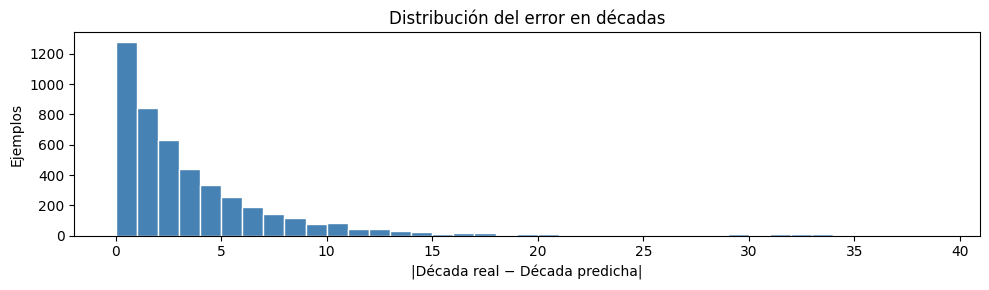

In [59]:
# ¿Cuánto se equivoca el modelo en número de décadas?
errors = np.abs(y_val.astype(int) - val_pred.astype(int))
print("Distribución de error (décadas de diferencia):")
for k in range(6):
    pct = (errors == k).mean() * 100
    print(f"  |error| = {k}:  {pct:.1f}%")
print(f"  |error| ≥ 6:  {(errors >= 6).mean()*100:.1f}%")

plt.figure(figsize=(10, 3))
plt.hist(errors, bins=range(0, 40), color='steelblue', edgecolor='white')
plt.xlabel('|Década real − Década predicha|')
plt.ylabel('Ejemplos'); plt.title('Distribución del error en décadas')
plt.tight_layout(); plt.show()

## 8. Guardar el modelo

In [60]:
joblib.dump(best_pipeline, 'modelo_parte1.joblib')
print("Modelo guardado en: modelo_parte1.joblib")

# Verificación
loaded = joblib.load('modelo_parte1.joblib')
check = loaded.predict(X_train[:5])
print(f"Predicciones (primeros 5): {check}")
print(f"Etiquetas reales:          {y_train[:5]}")

Modelo guardado en: modelo_parte1.joblib
Predicciones (primeros 5): [164 182 157 163 166]
Etiquetas reales:          [164 182 157 163 166]


## 9. Generación del archivo de respuesta (submission)

In [61]:
eval_pred  = best_pipeline.predict(X_eval)

submission = pd.DataFrame({
    'id':     df_eval['id'],
    'answer': eval_pred
})

submission.to_csv('data/answers.csv', index=False)
print(f"data/answers.csv generado: {len(submission)} predicciones")
print(f"Rango de décadas predichas: {eval_pred.min()} – {eval_pred.max()}")
print(f"Décadas únicas predichas:   {len(np.unique(eval_pred))}")
print()
print(submission.head(10).to_string(index=False))


data/answers.csv generado: 3490 predicciones
Rango de décadas predichas: 150 – 188
Décadas únicas predichas:   39

 id  answer
  0     173
  1     186
  2     150
  3     169
  4     153
  5     174
  6     170
  7     160
  8     161
  9     152


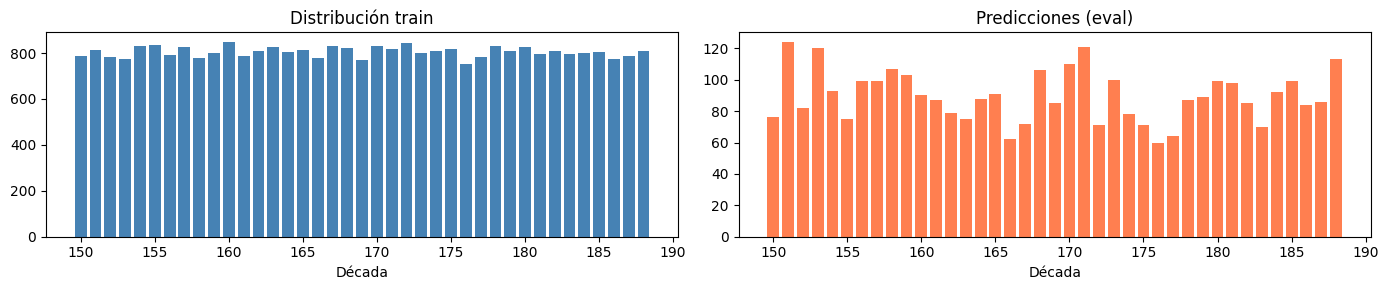

In [62]:
# Distribución de predicciones vs entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

vc_train = pd.Series(y_train).value_counts().sort_index()
vc_pred  = pd.Series(eval_pred).value_counts().sort_index()

axes[0].bar(vc_train.index, vc_train.values, color='steelblue')
axes[0].set_title('Distribución train'); axes[0].set_xlabel('Década')

axes[1].bar(vc_pred.index, vc_pred.values, color='coral')
axes[1].set_title('Predicciones (eval)'); axes[1].set_xlabel('Década')

plt.tight_layout(); plt.show()

## Resumen

| Componente | Detalle |
|---|---|
| **Paso 1** | `TfidfVectorizer(char, 3-5 grams, sublinear_tf, min_df=5, max_df=0.85)` |
| **Paso 2** | `SelectKBest(chi2, k=100000)` — filtrado estadístico |
| **Paso 3** | `LogisticRegression(saga, balanced, max_iter=200)` |
| **Búsqueda** | C ∈ {0.01, 0.1, 0.5, 1.0, 5.0} sobre holdout |
| **Análisis** | Top 10 n-gramas discriminativos por década |
| **Submission** | `data/answers.csv` |